In [1]:
from os.path import expanduser, join
from pynitride import ROOT_DIR, MaterialFunction
from pynitride.paramdb import ParamDB, Value
from pynitride.poissolve.snider import import_1dp_input, import_1dp_output, convert_1dpmat_to_PyNitride
from pynitride.poissolve.solvers import Coupled_Schrodinger_Poisson, KPSolver, Coupled_KP_Poisson
from pynitride.poissolve.visual import plot_carrierFV, plot_wavefunctions
import matplotlib.pyplot as plt
import numpy as np
cm,nm=ParamDB().get_constants("cm,nm")


Semi-classical success (max err=3.9e-16) after 2 refinement iterations
Full success (max err=5.1e-11) after 32 refinement iterations
Assembling: kx,ky= 0.0 0
fill
convert
about to eigsh  -0.48260479492296154
done eigsh
Assembling: kx,ky= 0.111111111111 0
fill
convert
about to eigsh  -0.48260479492296154
done eigsh
Assembling: kx,ky= 0.222222222222 0
fill
convert
about to eigsh  -0.48260479492296154
done eigsh
Assembling: kx,ky= 0.333333333333 0
fill
convert
about to eigsh  -0.48260479492296154
done eigsh
Assembling: kx,ky= 0.444444444444 0
fill
convert
about to eigsh  -0.48260479492296154
done eigsh
Assembling: kx,ky= 0.555555555556 0
fill
convert
about to eigsh  -0.48260479492296154
done eigsh
Assembling: kx,ky= 0.666666666667 0
fill
convert
about to eigsh  -0.48260479492296154
done eigsh
Assembling: kx,ky= 0.777777777778 0
fill
convert
about to eigsh  -0.48260479492296154
done eigsh
Assembling: kx,ky= 0.888888888889 0
fill
convert
about to eigsh  -0.48260479492296154
done eigsh
Assem

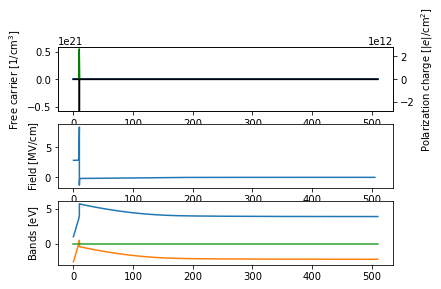

In [2]:
#stud=None


def doit():
    global energies,ns,weights,m,sm
    from pynitride.poissolve.devices import gan_pqwhemt
    m,sm=gan_pqwhemt(10,500,5e16/cm**3)
    csp=Coupled_Schrodinger_Poisson(m,schrodinger=sm)
    csp.solve(low_act=3,rise=40)
    kp=KPSolver(sm)
    kt,energies,ns,weights=kp.solve()
    #stud=energies
    #csp=Coupled_FD_Poisson(m)
    #csp.solve(callback=callback,rise=40)
    return m,sm,csp

if __name__=='__main__':
    #import cProfile
    #cProfile.run("doit()",'crestats.txt')
    m,sm,csp=doit()
    import matplotlib.pyplot as mpl
    mpl.interactive(True)
    plot_carrierFV(m)
    #plot_wavefunctions(sm,bands=['e_'])
    #plot_wavefunctions(sm,bands=['e_Gamma'])


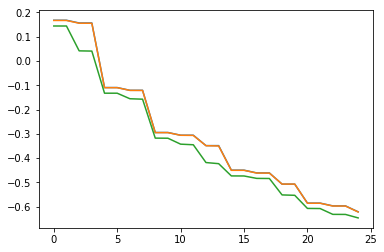

In [4]:
plt.figure()
plt.plot(energies[0])
plt.plot(energies[1])
plt.plot(energies[9])

In [5]:
#energies,ns,weights=kp.solve()

In [6]:
import numpy as np

In [7]:
np.diff(energies[14])

IndexError: index 14 is out of bounds for axis 0 with size 10

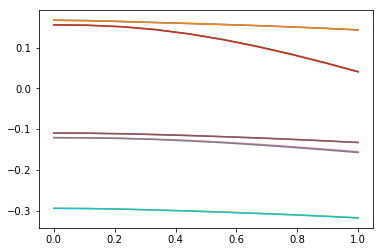

In [9]:
plt.figure();
for l in np.arange(10):
    plt.plot(np.linspace(0,1/nm,10),np.array([energies[kx][l] for kx in range(len(energies))]))
#plt.ylim(-.8,.1)

In [10]:
weights[0][:,1]

array([  4.89891621e-01,   4.89891621e-01,   1.71489024e-31,
         1.01083793e-02,   1.01083793e-02,   3.62152734e-30])

In [11]:
np.tile(np.atleast_2d(energies[0]).T,2)

array([[ 0.16718598,  0.16718598],
       [ 0.16718598,  0.16718598],
       [ 0.15588411,  0.15588411],
       [ 0.15588411,  0.15588411],
       [-0.10965481, -0.10965481],
       [-0.10965481, -0.10965481],
       [-0.12096522, -0.12096522],
       [-0.12096522, -0.12096522],
       [-0.29445861, -0.29445861],
       [-0.29445861, -0.29445861],
       [-0.30569204, -0.30569204],
       [-0.30569204, -0.30569204],
       [-0.34840718, -0.34840718],
       [-0.34840718, -0.34840718],
       [-0.44938242, -0.44938242],
       [-0.44938242, -0.44938242],
       [-0.46071551, -0.46071551],
       [-0.46071551, -0.46071551],
       [-0.50682507, -0.50682507],
       [-0.50682507, -0.50682507],
       [-0.58486466, -0.58486466],
       [-0.58486466, -0.58486466],
       [-0.59632986, -0.59632986],
       [-0.59632986, -0.59632986],
       [-0.62072508, -0.62072508]])

(5, 25)

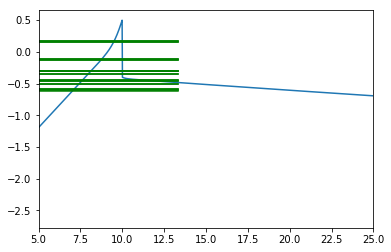

In [12]:
plt.plot(m._zp,m['Ev'])
#plt.twinx()
plt.plot(sm._zp,np.tile(np.atleast_2d(energies[0]).T,len(sm._zp)).T,'g')
plt.xlim(5,25)

(5, 25)

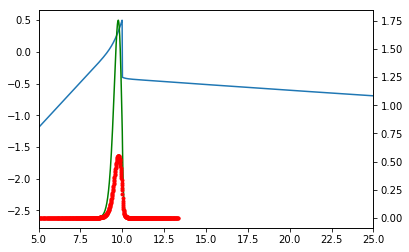

In [18]:
plt.plot(m._zp,m['Ev'])
plt.twinx()
plt.plot(sm._zp,ns[0][:,0],'g')
plt.plot(sm._zp,sm['p'],'.r')
plt.xlim(5,25)

In [65]:
ns=np.array(ns)
energies=np.array(energies)
kt=np.linspace(0,2/nm,20)

In [59]:
ns.shape

(20, 25, 578)

In [60]:
(energies).shape

(20, 25)

In [61]:
eta=energies/.025

In [64]:
(ns.T*np.log(1+np.exp(eta.T))).shape

(578, 25, 20)

In [ ]:
np.sum(mxys*(psi**2*(np.log(1+np.exp(eta)))).T,axis=1)

In [ ]:
np.sum(mxys*(psi**2*(np.log(1+np.exp(eta)))).T,axis=1)

In [ ]:
plt.figure();
for l in 24-np.arange(16):
    plt.plot(np.linspace(0,2/nm,20),np.array([energies[kx][l] for kx in range(len(energies))]))
#plt.ylim(-.8,.1)

In [20]:
s=np.array([[1,2],[2,4],[3,6],[4,8],[5,10],[6,12],[7,14],[8,16],[9,18],[10,20],[11,22],[12,24],[13,26],[14,28],[15,30],[16,32],[17,34],[18,35]])

In [59]:
sr=np.reshape(s,(3,6,2))

In [63]:
sr=np.rollaxis(np.reshape(s,(3,6,2)),2,1)

In [67]:
sr[:,0,0]

array([ 1,  7, 13])

In [68]:
sr[0,:,0]

array([1, 2])

In [69]:
sr[0,0,:]

array([1, 2, 3, 4, 5, 6])

In [76]:
np.array([0,0,1])*np.sqrt(np.sum(sr**2,axis=2)).T

array([[  0.        ,   0.        ,  38.19685851],
       [  0.        ,   0.        ,  75.92759709]])

In [85]:
(sr**2).T.shape

(6, 2, 3)

In [88]:
np.sum((sr**2).T/np.array([.1,.1,1]),axis=2)

array([[  669.,  2676.],
       [  876.,  3504.],
       [ 1125.,  4500.],
       [ 1416.,  5664.],
       [ 1749.,  6996.],
       [ 2124.,  8425.]])

In [79]:
np.sum(sr**2,axis=0)

array([[ 219,  264,  315,  372,  435,  504],
       [ 876, 1056, 1260, 1488, 1740, 1945]])

In [9]:
kp._kppar_p(0)

{'Delta1': 0.01,
 'Delta2': 0.0056666666666666671,
 'Delta3': 0.0056666666666666671,
 'L1': -0.31622850828349858,
 'L2': -0.31279952445873777,
 'M1': -0.057149730412680511,
 'M2': -0.058292725020934133,
 'M3': -0.054863741196173259,
 'N1m': -0.057149730412680511,
 'N1p': -0.20192904745813753,
 'N2m': -0.058292725020934133,
 'N2p': -0.20572555950862348}

In [10]:
kp._C2w(**kp._kppar_p(0),kx=0,ky=0)

array([[-0.0201929,  0.       ,  0.       ,  0.       ,  0.       ,  0.       ],
       [ 0.       , -0.0201929,  0.       ,  0.       ,  0.       ,  0.       ],
       [ 0.       ,  0.       , -0.2746997,  0.       ,  0.       ,  0.       ],
       [ 0.       ,  0.       ,  0.       , -0.0201929,  0.       ,  0.       ],
       [ 0.       ,  0.       ,  0.       ,  0.       , -0.0201929,  0.       ],
       [ 0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        -0.2746997]])

In [13]:
kz=0
H=lambda kx,kz: kp._C0w(**kp._kppar_p(0),kx=kx,ky=0)+kp._Clw(**kp._kppar_p(0),kx=kx,ky=0)*kz+kp._Crw(**kp._kppar_p(0),kx=0,ky=0)*kz+kp._C2w(**kp._kppar_p(0),kx=kx,ky=0)*kz**2

In [14]:
from scipy.linalg import eigh
import numpy as np
kz=np.linspace(0,2/nm)
en=[]
for kzi in kz:
    en+=[eigh(H(0,kzi))[0]]

(-0.5, 0.1)

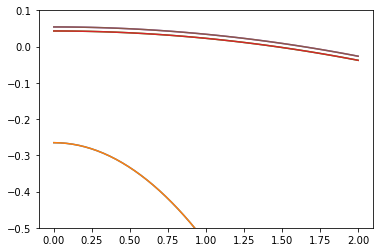

In [17]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(kz,np.array(en))
plt.ylim(-.5,.1)

In [18]:
from scipy.linalg import eigh
import numpy as np
kx=np.linspace(0,2/nm)
en=[]
for kxi in kx:
    en+=[eigh(H(kxi,0))[0]]

(-0.5, 0.1)

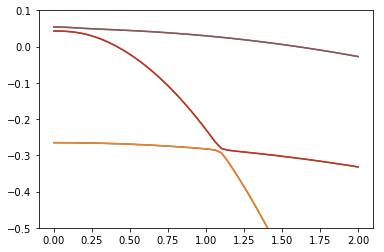

In [19]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(kx,np.array(en))
plt.ylim(-.5,.1)

# SAM

Semi-classical success (max err=3.9e-16) after 2 refinement iterations
Full success (max err=5.1e-11) after 32 refinement iterations
Assembling: kx,ky= 0.0 0
fill
convert
about to eigsh  -0.48260479492296066
done eigsh
Assembling: kx,ky= 0.111111111111 0
fill
convert
about to eigsh  -0.48260479492296066
done eigsh
Assembling: kx,ky= 0.222222222222 0
fill
convert
about to eigsh  -0.48260479492296066
done eigsh
Assembling: kx,ky= 0.333333333333 0
fill
convert
about to eigsh  -0.48260479492296066
done eigsh
Assembling: kx,ky= 0.444444444444 0
fill
convert
about to eigsh  -0.48260479492296066
done eigsh
Assembling: kx,ky= 0.555555555556 0
fill
convert
about to eigsh  -0.48260479492296066
done eigsh
Assembling: kx,ky= 0.666666666667 0
fill
convert
about to eigsh  -0.48260479492296066
done eigsh
Assembling: kx,ky= 0.777777777778 0
fill
convert
about to eigsh  -0.48260479492296066
done eigsh
Assembling: kx,ky= 0.888888888889 0
fill
convert
about to eigsh  -0.48260479492296066
done eigsh
Assem

done eigsh
Assembling: kx,ky= 1.0 0
fill
convert
about to eigsh  -0.572955090107981
done eigsh
WHY AM I ONLY LOOKING AT K=0 ^^^
not blending


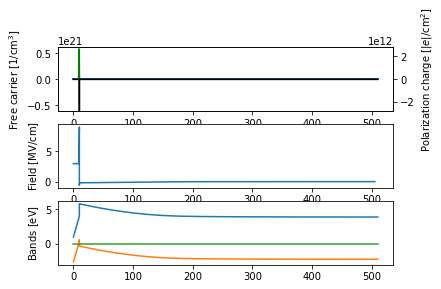

In [19]:
#stud=None


def doit():
    global energies,ns,weights,m,sm
    from pynitride.poissolve.devices import gan_pqwhemt
    m,sm=gan_pqwhemt(10,500,5e16/cm**3)
    csp=Coupled_KP_Poisson(m,schrodinger=sm)
    csp.solve(low_act=3,rise=40)
    kp=KPSolver(sm)
    kt,energies,ns,weights=kp.solve()
    return m,sm,csp

if __name__=='__main__':
    #import cProfile
    #cProfile.run("doit()",'crestats.txt')
    m,sm,csp=doit()
    import matplotlib.pyplot as mpl
    mpl.interactive(True)
    plot_carrierFV(m)
    #plot_wavefunctions(sm,bands=['e_'])
    #plot_wavefunctions(sm,bands=['e_Gamma'])


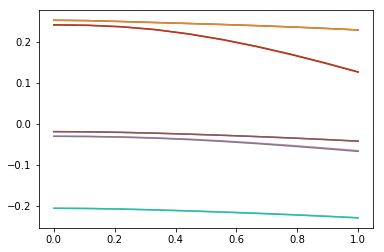

In [30]:
plt.figure();
k=np.linspace(0,1/nm,10);
lvs=[]
for l in np.arange(10):
    E=np.array([energies[kx][l] for kx in range(len(energies))])
    plt.plot(k,E)
    lvs+=[E]
#plt.ylim(-.8,.1)

In [31]:
lvs[0]

array([ 0.25240544,  0.25149203,  0.24929965,  0.24684912,  0.24447583,
        0.24199969,  0.23925361,  0.23615156,  0.23265155,  0.22873213])

In [26]:
m['p'].integrate(definite=True)*cm**2   /1e13

Function(3.7577716468208298)

In [16]:
np.exp([1,100])/(1+np.exp([1,100]))**2

array([  1.96611933e-01,   3.72007598e-44])

In [26]:
np.exp(-1800)

0.0

In [3]:
from pynitride.poissolve.maths import idd

In [4]:
idd([1,2,3],.5)

array([ 0.42388312,  0.21301396,  0.090557  ])

In [5]:
import numpy as np
1/(1+.5*np.exp([1,2,3]))

array([ 0.42388312,  0.21301396,  0.090557  ])